# Contracted river graph data gate

## tl;dr

This notebook audits whether the contracted real daily graph is ready for formal RiverLagNet training. The gate requires a directed acyclic monitored graph, at least 90% original-observation coverage for every target at every selected node, a chronological daily panel, and an explicit account of travel-time priors beyond the 14-day candidate lag.

## Context & Methods

Nodes are monitored HydroRIVERS reaches. Each edge follows `NEXT_DOWN` through any unmonitored reaches until the first selected downstream reach; path length and hop count are accumulated. Selection first requires minimum NH3N/CODMn/TP original-observation coverage of 0.90, then chooses the largest connected component with 3–256 nodes. Travel time is a routing prior computed as contracted path length divided by an assumed 30 km/day speed; it is not a causal estimate.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():
    ROOT = ROOT.parent
assert (ROOT / 'pyproject.toml').is_file(), 'run from the RiverLagNet repository'
DATA_ROOT = ROOT / 'data/processed/china-real-daily-contracted-v0.2'
GRAPH_SUMMARY_PATH = ROOT / 'experiments/china_real_daily_contracted_graph_summary.json'
OLD_GRAPH_SUMMARY_PATH = ROOT / 'experiments/china_real_daily_graph_summary.json'
MANIFEST_PATH = DATA_ROOT / 'manifest.json'

manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
graph = json.loads(GRAPH_SUMMARY_PATH.read_text(encoding='utf-8'))
construction = manifest['graph_construction']
old_graph = json.loads(OLD_GRAPH_SUMMARY_PATH.read_text(encoding='utf-8')) if OLD_GRAPH_SUMMARY_PATH.exists() else None
print(f"Loaded {manifest['dataset_id']} with shape {manifest['shape']}")

Loaded china-real-daily-contracted-v0.2 with shape [3972, 238, 3]


## Data

The audit uses the prepared dataset manifest and the machine-readable graph summary generated from the same NPZ, edge Parquet, and station-mapping Parquet artifacts. Counts refer to 3,972 daily timestamps from 1 April 2014 through 13 February 2025.

In [2]:
checks = {
    'direction_is_upstream_to_downstream': graph['direction'] == 'upstream_to_downstream',
    'selected_graph_is_directed_forest': construction['selected_graph_is_directed_forest'],
    'edge_count_matches_tree_identity': graph['edge_count'] == graph['node_count'] - graph['component_count'],
    'minimum_target_coverage_at_least_90pct': construction['selected_min_target_coverage']['min'] >= 0.90,
    'all_three_prepared_observation_rates_complete': min(manifest['observed_rates'].values()) == 1.0,
    'daily_panel_has_required_length': manifest['shape'][0] >= 90 + 30,
    'no_imputed_values_used_as_observations': not manifest['imputed_values_used_as_observations'],
}
for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL':4s}  {name}")
assert all(checks.values()), 'formal-training data gate failed'

PASS  direction_is_upstream_to_downstream
PASS  selected_graph_is_directed_forest
PASS  edge_count_matches_tree_identity
PASS  minimum_target_coverage_at_least_90pct
PASS  all_three_prepared_observation_rates_complete
PASS  daily_panel_has_required_length
PASS  no_imputed_values_used_as_observations


## Results

The selected graph passes the formal-training gate. The first panel compares the earlier 36-node direct-adjacency pilot with the 238-node contracted component; this is a scope comparison, not a controlled performance comparison. The second panel shows that most path priors now occupy non-zero lag ranges, while the orange bin identifies edges that exceed the current 14-day model support.

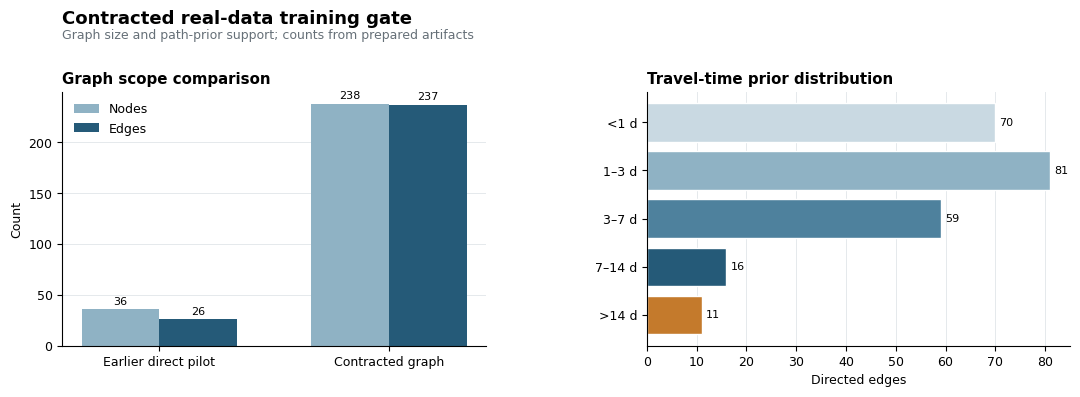

In [3]:
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 9})
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.1), gridspec_kw={'wspace': 0.38})

labels = ['Earlier direct pilot', 'Contracted graph']
node_values = [old_graph['node_count'] if old_graph else 36, graph['node_count']]
edge_values = [old_graph['edge_count'] if old_graph else 26, graph['edge_count']]
x = np.arange(2)
width = 0.34
axes[0].bar(x - width / 2, node_values, width, color='#8FB2C4', label='Nodes')
axes[0].bar(x + width / 2, edge_values, width, color='#255A78', label='Edges')
axes[0].set_xticks(x, labels)
axes[0].set_ylabel('Count')
axes[0].set_title('Graph scope comparison', loc='left', fontweight='bold')
axes[0].legend(frameon=False)
for container in axes[0].containers:
    axes[0].bar_label(container, padding=2, fontsize=8)

lag_labels = list(graph['prior_lag_bin_counts'])
lag_values = [graph['prior_lag_bin_counts'][label] for label in lag_labels]
lag_colors = ['#C9D9E2', '#8FB2C4', '#4E819D', '#255A78', '#C47A2C']
bars = axes[1].barh(lag_labels, lag_values, color=lag_colors, edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_xlabel('Directed edges')
axes[1].set_title('Travel-time prior distribution', loc='left', fontweight='bold')
axes[1].bar_label(bars, padding=3, fontsize=8)

for axis in axes:
    axis.spines[['top', 'right']].set_visible(False)
    axis.grid(axis='y' if axis is axes[0] else 'x', color='#E5E9EC', linewidth=0.7)
    axis.set_axisbelow(True)
fig.suptitle('Contracted real-data training gate', x=0.07, ha='left', fontsize=13, fontweight='bold')
fig.text(0.07, 0.91, 'Graph size and path-prior support; counts from prepared artifacts', color='#667078')
fig.subplots_adjust(top=0.78, bottom=0.16, left=0.07, right=0.97)
output_png = ROOT / 'docs/figures/china_real_daily_contracted_data_gate.png'
output_pdf = ROOT / 'docs/figures/china_real_daily_contracted_data_gate.pdf'
fig.savefig(output_png, dpi=300, facecolor='white')
fig.savefig(output_pdf, facecolor='white')
plt.show()

In [4]:
print('Selected nodes:', construction['selected_segment_count'])
print('Selected edges:', construction['selected_edge_count'])
print('Source stations:', construction['selected_source_station_count'])
print('Minimum selected target coverage:', construction['selected_min_target_coverage']['min'])
print('Median travel-time prior (days):', round(construction['travel_time_prior_days']['median'], 3))
print('P90 travel-time prior (days):', round(construction['travel_time_prior_days']['p90'], 3))
print('Edges above max lag:', construction['travel_time_prior_above_max_lag_count'])
print('Mapping-review segments:', construction['selected_mapping_review_segment_count'])

Selected nodes: 238
Selected edges: 237
Source stations: 283
Minimum selected target coverage: 1.0
Median travel-time prior (days): 2.088
P90 travel-time prior (days): 7.191
Edges above max lag: 11
Mapping-review segments: 12


## Takeaways

- Proceed to Lightning smoke validation and the first formal paired baseline/full-model run on the contracted dataset.
- Keep `max_lag=14` for the first controlled comparison, but treat the 11 longer-prior edges as a declared truncation limitation and schedule a 28-day sensitivity experiment.
- Report the 12 mapping-review segments and later run an exclusion sensitivity; mapping review is a geospatial uncertainty flag, not a reason to overwrite observations.
- Do not interpret learned attention weights as causal contributions.